In [2]:
#expected_return
import sys
sys.path.append('..')

from risk_engine.data_loader import get_market_data
import pandas as pd
import numpy as np

tickers = ['SPY', 'TLT', 'GLD']
prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

expected_return = returns.mean() * 252

print(f"expected_return: {expected_return}")

[*********************100%***********************]  3 of 3 completed

expected_return: Ticker
GLD    0.116334
SPY    0.155639
TLT   -0.048568
dtype: float64


In [12]:
#volatility

import numpy as np

volatility = returns.std() * np.sqrt(252)

print(f"annualized volatility: {volatility}")



annualized volatility: Ticker
GLD    0.155251
SPY    0.209973
TLT    0.179638
dtype: float64


In [1]:
import sys
sys.path.append('..')

from risk_engine.data_loader import get_market_data

from risk_engine.risk_metrics import volatility

tickers = ['SPY', 'TLT', 'GLD']
prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

print(volatility(returns))


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed

Ticker
GLD    0.155251
SPY    0.209973
TLT    0.179638
dtype: float64


In [ ]:
#Var (Value at Risk)

# Although a negative #, its formatted in a way of Var = X% loss. 

def hist_var(asset_returns, confidence_level=0.95):
    var = asset_returns.quantile(1-confidence_level)
    return (var)

print(hist_var(asset_returns=returns))


Ticker
GLD   -0.015887
SPY   -0.019253
TLT   -0.017264
Name: 0.050000000000000044, dtype: float64


In [25]:
# CVaR (Conditional VaR)

def cvar(asset_returns, confidence_level=0.95):
    var_threshold = hist_var(asset_returns, confidence_level)
    bad_returns = asset_returns[asset_returns < var_threshold]
    return bad_returns.mean()

print(cvar(asset_returns=returns))

Ticker
GLD   -0.022800
SPY   -0.031951
TLT   -0.023830
dtype: float64


In [ ]:
# Correlation Matrix

def correlation_matrix(asset_returns):
    return asset_returns.corr()

print(correlation_matrix(returns))




Ticker       GLD       SPY       TLT
Ticker                              
GLD     1.000000  0.157949  0.266153
SPY     0.157949  1.000000 -0.150094
TLT     0.266153 -0.150094  1.000000


In [33]:
# Beta


def beta(asset_returns, market_returns):

    covariance = asset_returns.cov(market_returns)
    m_var = market_returns.var()
    return covariance / m_var

print(beta(returns['TLT'], returns['SPY']))








-0.1284101053074582


In [ ]:
# portfolio expected return

from risk_engine.risk_metrics import expected_return

def portfolio_expected_return(asset_returns, weights):

    individual_returns = expected_return(asset_returns)
    portfolio_returns = (individual_returns * weights).sum()
    return portfolio_returns

weights = np.array([0.33, 0.33, 0.34])

print(portfolio_expected_return(returns, weights))




0.07323788146689078


In [44]:
# portfolio volatility


def portfolio_vol(asset_returns, weights):
    cov_matrix = asset_returns.cov() * 252
    return np.sqrt(weights.T @ cov_matrix @ weights)

weights = np.array([0.33, 0.33, 0.34])

print(portfolio_vol(returns, weights))



0.11257484006165117


[*********************100%***********************]  3 of 3 completed


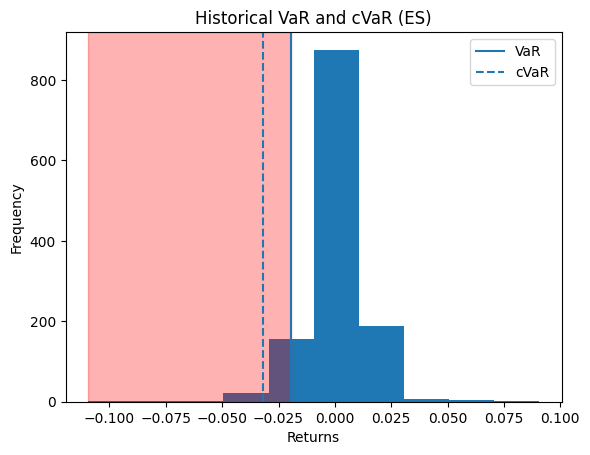

(<matplotlib.legend.Legend at 0x1d07a1b2f50>, None)

In [6]:
#Visualization

import matplotlib.pyplot as plt

from risk_engine.data_loader import get_market_data

from risk_engine.risk_metrics import hist_var, cvar

tickers = ['SPY', 'TLT', 'GLD']
prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

def visualization(returns, var, cvar):
    plt.hist(returns)
    plt.axvline(var, label='VaR')
    plt.axvline(cvar, linestyle='dashed', label='cVaR')
    plt.axvspan(xmin=returns.min().min(), xmax=var, color='red', alpha=0.3)
    plt.title('Historical VaR and cVaR (ES)')
    plt.xlabel('Returns')
    plt.ylabel('Frequency')

    return plt.legend(), plt.show()
  

visualization(returns=returns['SPY'], var=hist_var(returns['SPY']), cvar=cvar(returns['SPY']))

